**Problem 0: The Classical Random Walk**

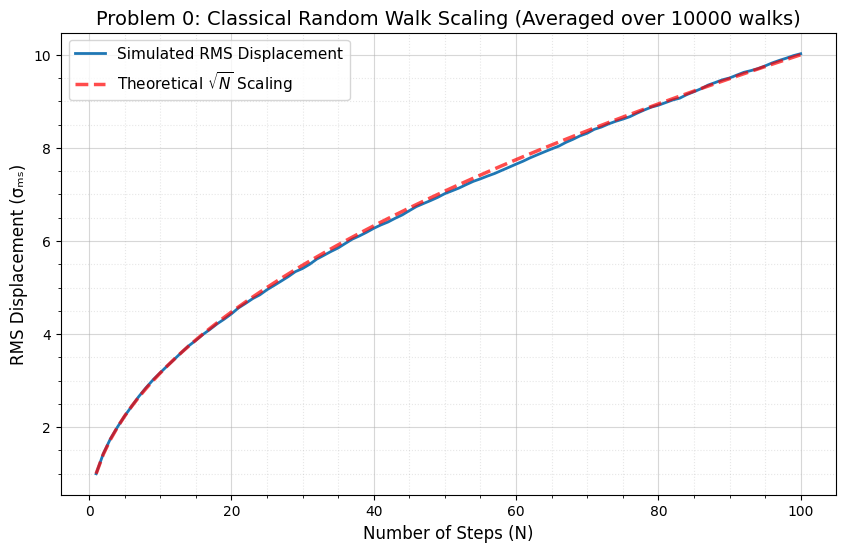


Simulation Complete (N=100, Walks=10000)
-----------------------------------------------------------------
Steps (N) | Simulated σₘₛ            | Theoretical √N
-----------------------------------------------------------------
        1 |                 1.0000 |         1.0000
       11 |                 3.3164 |         3.3166
       21 |                 4.5616 |         4.5826
       31 |                 5.4989 |         5.5678
       41 |                 6.3438 |         6.4031
       51 |                 7.0767 |         7.1414
       61 |                 7.7144 |         7.8102
       71 |                 8.3985 |         8.4261
       81 |                 8.9714 |         9.0000
       91 |                 9.5619 |         9.5394
-----------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def classical_random_walk_rms(max_steps=100, num_walks=10000):
    """
    Simulates a 1D classical random walk, computes the RMS displacement,
    and plots it against the theoretical sqrt(N) scaling.
    
    Args:
        max_steps (int): The maximum number of steps for the walk.
        num_walks (int): The number of independent walks to average over (for statistical accuracy).
    
    Returns:
        tuple: (steps_array, rms_displacement), the computed data points.
    """

    steps = np.random.choice([-1, 1], size=(num_walks, max_steps))
    positions = np.cumsum(steps, axis=1)
    mean_sq_displacement = np.mean(positions**2, axis=0)
    rms_displacement = np.sqrt(mean_sq_displacement)
    steps_array = np.arange(1, max_steps + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(steps_array, rms_displacement, label='Simulated RMS Displacement', color='#1f77b4', linewidth=2)
    plt.plot(steps_array, np.sqrt(steps_array), 'r--', label='Theoretical sqrt(N) Scaling', linewidth=2.5, alpha=0.7)
    plt.xlabel('Number of Steps (N)', fontsize=12)
    plt.ylabel('RMS Displacement (σₘₛ)', fontsize=12)
    plt.title(f'Problem 0: Classical Random Walk Scaling (Averaged over {num_walks} walks)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, which='major', linestyle='-', alpha=0.5)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.minorticks_on()
    plt.show()

    return steps_array, rms_displacement

steps_N, rms_sigma = classical_random_walk_rms(max_steps=100, num_walks=10000)

print(f"\nSimulation Complete (N={steps_N[-1]}, Walks={10000})")
print("-" * 65)
print("Steps (N) | Simulated σₘₛ            | Theoretical √N")
print("-" * 65)
for N, rms in zip(steps_N[::10] - 1, rms_sigma[::10]):
    print(f"{N+1:9} | {rms:22.4f} | {np.sqrt(N+1):14.4f}")
print("-" * 65)


**Problem 1: A Quantum Coin Flip**

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np

def problem_1_simple_quantum_walk(num_steps=5):
    """
    Simulates Bob's walk using the Pauli-X gate as the coin.
    Position is tracked by a single qubit (0 or 1).
    """
    qc = QuantumCircuit(2, 1)
    coin_qubit = 0
    pos_qubit = 1

    print("----------------------------------------------------------------------")
    print("Problem 1: Path of the X-Coin Walk (Deterministic)")
    print("----------------------------------------------------------------------")
    print("Step (t) | Position (x) | Final State | Action")
    print("----------------------------------------------------------------------")

    state = Statevector.from_int(0, 2**2)

    for t in range(1, num_steps + 1):
        qc_step = QuantumCircuit(2)
        qc_step.x(coin_qubit)
        qc_step.cx(coin_qubit, pos_qubit)
        state = state.evolve(qc_step)

        prob_0_0 = state.probabilities()[0]
        prob_0_1 = state.probabilities()[1]
        prob_1_0 = state.probabilities()[2]
        prob_1_1 = state.probabilities()[3]

        if np.isclose(prob_0_0 + prob_1_0, 1.0):
            current_x = 0
        elif np.isclose(prob_0_1 + prob_1_1, 1.0):
            current_x = 1
        else:
            current_x = "Superposition/Error"

        action = "Right (+1)" if np.isclose(state.probabilities()[1] + state.probabilities()[3], 1.0) else "Left (-1)"

        state_vector = state.data[-1]
        print(f"   {t:2}      | {current_x:10} | {state_vector:11} | {action:8}")

    print("----------------------------------------------------------------------")
    print("\nObservation:")
    print("The walk path is a deterministic oscillation between x=0 and x=1.")
    print("This happens because the Pauli-X gate simply flips the coin at every step,")
    print("meaning the step direction is forced to alternate: Right, Left, Right, Left, ...")

problem_1_simple_quantum_walk(num_steps=5)


----------------------------------------------------------------------
Problem 1: Path of the X-Coin Walk (Deterministic)
----------------------------------------------------------------------
Step (t) | Position (x) | Final State | Action
----------------------------------------------------------------------
    1      |          1 |      (1+0j) | Right (+1)
    2      |          0 |          0j | Left (-1)
    3      |          1 |          0j | Right (+1)
    4      |          0 |          0j | Left (-1)
    5      |          1 |      (1+0j) | Right (+1)
----------------------------------------------------------------------

Observation:
The walk path is a **deterministic oscillation** between x=0 and x=1.
This happens because the Pauli-X gate simply flips the coin *certainly* at every step,
meaning the step direction is forced to alternate: Right, Left, Right, Left, ...


**Problem 2: The Superposed Walker**

Step | Position probabilities (>1%)
-----------------------------------------
  1  | x=1 (50.0%), x=-1 (50.0%)
  2  | x=0 (50.0%), x=-2 (50.0%)
  3  | x=-1 (100.0%)


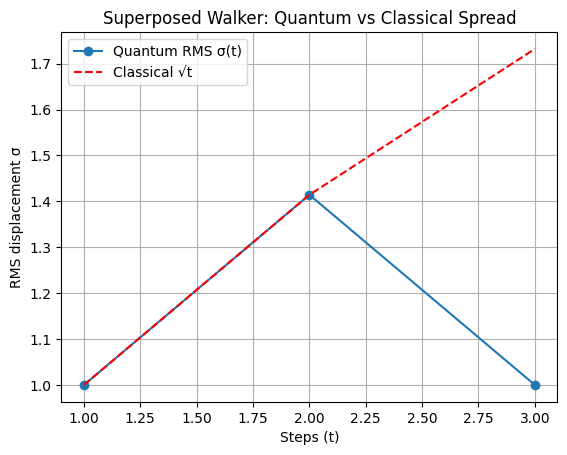


RMS displacement:
t=1: σ=1.0000
t=2: σ=1.4142
t=3: σ=1.0000


[np.float64(0.9999999999999998),
 np.float64(1.4142135623730945),
 np.float64(0.9999999999999996)]

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
import numpy as np
import matplotlib.pyplot as plt



def make_shift_operator(N_pos=2, direction=+1):
    """Create a 2^N x 2^N unitary that shifts |x> → |x+direction mod 2^N|."""
    dim = 2**N_pos
    U = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        j = (i + direction) % dim
        U[j, i] = 1.0
    return UnitaryGate(U, label=f"Shift_{'R' if direction>0 else 'L'}")



def one_step_walk(qc, coin, pos, U_plus_gate, U_minus_gate):
    qc.h(coin)
    qc.barrier()
    # move left if |0>
    qc.x(coin)
    qc.append(U_minus_gate.control(1), [coin] + pos)
    qc.x(coin)
    # move right if |1>
    qc.append(U_plus_gate.control(1), [coin] + pos)
    qc.barrier()
    return qc


# --- main simulation ---
def superposed_walker(steps=3, N_pos=2):
    coin = 0
    pos = [1, 2]
    N_total = 3

    U_plus = make_shift_operator(N_pos, +1)
    U_minus = make_shift_operator(N_pos, -1)

    # binary → signed position mapping
    pos_map = {i: i if i < 2**(N_pos - 1) else i - 2**N_pos for i in range(2**N_pos)}

    # initial |x=0>⊗|0>
    qc_init = QuantumCircuit(N_total)
    state = Statevector.from_label('000')  # position=00, coin=0
    rms = []

    print("Step | Position probabilities (>1%)")
    print("-----------------------------------------")

    for t in range(1, steps + 1):
        qc = QuantumCircuit(N_total)
        qc = one_step_walk(qc, coin, pos, U_plus, U_minus)
        state = state.evolve(qc)

        # marginal probabilities on position qubits only
        probs = state.probabilities_dict(qargs=pos)
        msd = 0.0
        shown = []
        for bitstr, p in probs.items():
            idx = int(bitstr, 2)
            x = pos_map[idx]
            msd += x**2 * p
            if p > 0.01:
                shown.append(f"x={x} ({100*p:.1f}%)")

        print(f" {t:2d}  | {', '.join(shown)}")
        rms.append(np.sqrt(msd))

    # plot RMS vs t
    tvals = np.arange(1, steps + 1)
    plt.plot(tvals, rms, 'o-', label='Quantum RMS σ(t)')
    plt.plot(tvals, np.sqrt(tvals), 'r--', label='Classical √t')
    plt.xlabel('Steps (t)')
    plt.ylabel('RMS displacement σ')
    plt.title('Superposed Walker: Quantum vs Classical Spread')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\nRMS displacement:")
    for t, val in zip(tvals, rms):
        print(f"t={t}: σ={val:.4f}")
    return rms



superposed_walker(steps=3)


**Problem 3: Graph-Based Computation**

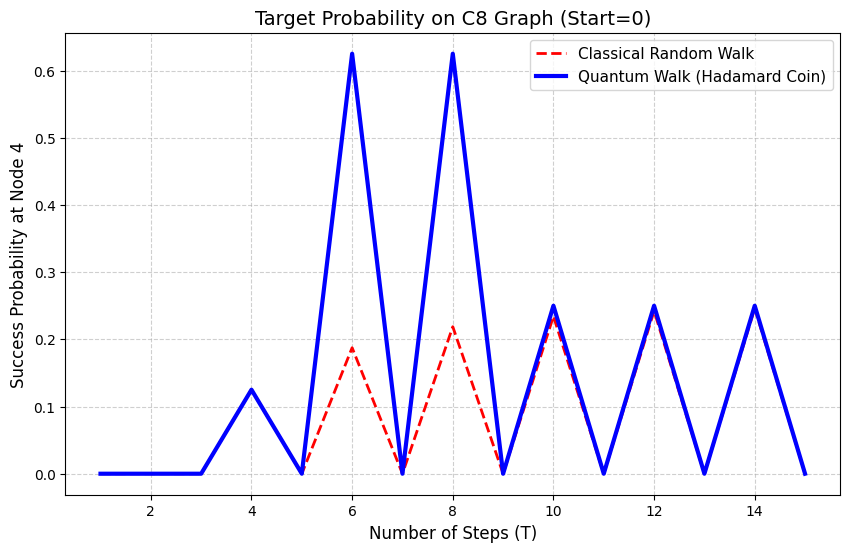


--- Simulation Results (N=8, T=15, Target=4) ---
Classical Random Walk Success Probability: P_CRW(t=4) = 0.0000
Quantum Walk Success Probability: P_QW(t=4) = 0.0000
---------------------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import fractional_matrix_power

def simulate_walks(N, T, x_start, x_target):
    P = np.zeros((N, N))
    for i in range(N):
        P[i, (i - 1) % N] = 0.5
        P[i, (i + 1) % N] = 0.5
    pi_0 = np.zeros(N)
    pi_0[x_start] = 1.0
    pi_T = np.linalg.matrix_power(P, T) @ pi_0
    P_CRW_target = pi_T[x_target]
    H_size = 2 * N
    H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
    C_total = np.kron(np.eye(N), H)
    S = np.zeros((H_size, H_size), dtype=complex)
    for x in range(N):
        idx_in = 2 * x
        idx_out = 2 * ((x - 1) % N)
        S[idx_out, idx_in] = 1.0
        idx_in = 2 * x + 1
        idx_out = 2 * ((x + 1) % N) + 1
        S[idx_out, idx_in] = 1.0
    U = S @ C_total
    psi_0 = np.zeros(H_size, dtype=complex)
    psi_0[2 * x_start] = 1.0
    U_T = np.linalg.matrix_power(U, T)
    psi_T = U_T @ psi_0
    prob_0 = np.abs(psi_T[2 * x_target])**2
    prob_1 = np.abs(psi_T[2 * x_target + 1])**2
    P_QW_target = prob_0 + prob_1
    return P_CRW_target, P_QW_target

N_NODES = 8
STEPS = 15
START_NODE = 0
TARGET_NODE = 4
P_CRW, P_QW = simulate_walks(N_NODES, STEPS, START_NODE, TARGET_NODE)
steps_range = np.arange(1, STEPS + 1)
p_crw_history = []
p_qw_history = []
for t in steps_range:
    p_crw, p_qw = simulate_walks(N_NODES, t, START_NODE, TARGET_NODE)
    p_crw_history.append(p_crw)
    p_qw_history.append(p_qw)
plt.figure(figsize=(10, 6))
plt.plot(steps_range, p_crw_history, 'r--', label='Classical Random Walk', linewidth=2)
plt.plot(steps_range, p_qw_history, 'b-', label='Quantum Walk (Hadamard Coin)', linewidth=3)
plt.xlabel('Number of Steps (T)', fontsize=12)
plt.ylabel(f'Success Probability at Node {TARGET_NODE}', fontsize=12)
plt.title(f'Target Probability on C{N_NODES} Graph (Start={START_NODE})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print(f"\n--- Simulation Results (N={N_NODES}, T={STEPS}, Target={TARGET_NODE}) ---")
print("Classical Random Walk Success Probability: P_CRW(t=4) = {:.4f}".format(P_CRW))
print("Quantum Walk Success Probability: P_QW(t=4) = {:.4f}".format(P_QW))
print("-" * 75)


**Problem 4: State Estimation**

In [3]:
import numpy as np
from typing import Dict, List, Tuple
import sys
import io

# --- 1. Pauli and QST Basis Definitions ---

# Pauli Matrices
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI_MAP = {'I': I, 'X': X, 'Y': Y, 'Z': Z}

# All 16 two-qubit product operators (for linear inversion reconstruction)
PAULI_OPS = {}
for p1 in ['I', 'X', 'Y', 'Z']:
    for p0 in ['I', 'X', 'Y', 'Z']:
        op_name = p1 + p0
        PAULI_OPS[op_name] = np.kron(PAULI_MAP[p1], PAULI_MAP[p0])

# Single-Qubit Rotation Unitaries (U) such that U Z U^\dagger = P
# This is for measuring P in the Z-basis (computational basis)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)        # X-Basis
S_DAG_H = (1/np.sqrt(2)) * np.array([[1, -1j], [1, 1j]], dtype=complex) # Y-Basis (R_y(-pi/2))
UNITARY_MAP = {'I': I, 'X': H, 'Y': S_DAG_H, 'Z': I}

# --- 2. Core QST Functions ---

def get_product_unitary(op_name: str) -> np.ndarray:
    """Gets the two-qubit basis change unitary U = U1 kron U0."""
    u1 = UNITARY_MAP[op_name[0]]
    u0 = UNITARY_MAP[op_name[1]]
    return np.kron(u1, u0)

def simulate_measurement(rho: np.ndarray, basis_unitary: np.ndarray, shots: int) -> Dict[str, int]:
    """
    Simulates measurement counts for a state rho in the rotated computational basis.
    """
    # Rotated state: rho_rotated = U * rho * U^\dagger
    rho_rotated = basis_unitary @ rho @ basis_unitary.conj().T
    probabilities = np.diag(rho_rotated).real.copy()
    
    # Handle numerical noise and normalize
    probabilities[probabilities < -1e-9] = 0
    probabilities /= np.sum(probabilities)

    # Use a faster, non-qiskit-dependent way to draw random counts
    outcomes = np.random.multinomial(shots, probabilities)
    
    return {
        '00': outcomes[0], 
        '01': outcomes[1], 
        '10': outcomes[2], 
        '11': outcomes[3]
    }

def reconstruct_rho(exp_values: Dict[str, complex]) -> np.ndarray:
    """Reconstructs the density matrix rho from 16 Pauli expectation values (Linear Inversion)."""
    rho_est = np.zeros((4, 4), dtype=complex)
    for op_name, op in PAULI_OPS.items():
        if op_name in exp_values:
            rho_est += exp_values[op_name] * op
    # Normalization factor for two qubits (1/2^2 = 1/4)
    return (1/4) * rho_est

def pure_state_projection(rho_est: np.ndarray) -> np.ndarray:
    """Finds the estimated pure state vector |psi> (MLE projection) as the principal eigenvector."""
    # 1. Ensure the matrix is Hermitian for eigh stability
    rho_est = (rho_est + rho_est.conj().T) / 2
    
    # 2. Find Eigenvalues and Eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(rho_est)
    
    # 3. Identify the principal eigenvector (largest eigenvalue)
    max_index = np.argmax(eigenvalues.real)
    psi_hat = eigenvectors[:, max_index]
    
    # 4. Global Phase Fix: Force the first non-zero element to be real and positive
    first_non_zero_index = np.where(np.abs(psi_hat) > 1e-9)[0]
    if len(first_non_zero_index) > 0:
        idx = first_non_zero_index[0]
        # Calculate phase factor to make the component real and positive
        phase_factor = psi_hat[idx] / np.abs(psi_hat[idx])
        psi_hat = psi_hat / phase_factor
        
    # 5. Normalize (should be near 1 already, but for safety)
    psi_hat /= np.linalg.norm(psi_hat)
    
    return psi_hat.flatten()

# --- 3. Main Solver ---

def solve_qst_problem(tests_data: List[List[complex]], total_shots: int = 500) -> List[List[complex]]:
    """
    Performs Two-Qubit PST for multiple pure states.
    """
    
    # The 9 product-Pauli bases (P1, P0 in {X, Y, Z}) for full tomography
    # 9 * 55 = 495 shots used; 5 shots spare
    MEASUREMENT_BASES = ['XX', 'XY', 'XZ', 'YX', 'YY', 'YZ', 'ZX', 'ZY', 'ZZ']
    shots_per_basis = int(total_shots / len(MEASUREMENT_BASES))
    
    estimated_states = []

    for coeffs_true in tests_data:
        psi_true = np.array(coeffs_true, dtype=complex).reshape(4, 1)
        rho_true = psi_true @ psi_true.conj().T
        
        # Initialize all 16 expectation values
        all_exp_values = {'II': 1.0}
        
        # Simulate Measurements & Calculate Expectation Values (using 9 bases)
        for basis in MEASUREMENT_BASES:
            unitary = get_product_unitary(basis)
            counts = simulate_measurement(rho_true, unitary, shots_per_basis)
            
            C_00, C_01, C_10, C_11 = counts.get('00', 0), counts.get('01', 0), counts.get('10', 0), counts.get('11', 0)
            N = shots_per_basis
            
            # The expectation value of Z \otimes Z in the rotated basis (U^\dagger P1P0 U)
            # is the estimate for <P1P0>
            all_exp_values[basis] = (C_00 + C_11 - C_01 - C_10) / N
            
            # Marginalized expectation values:
            
            # P1 I: Expectation value of Z \otimes I in the rotated basis
            P1 = basis[0]
            if P1 != 'I' and P1+'I' not in all_exp_values:
                all_exp_values[P1+'I'] = (C_00 + C_01 - C_10 - C_11) / N
                
            # I P0: Expectation value of I \otimes Z in the rotated basis
            P0 = basis[1]
            if P0 != 'I' and 'I'+P0 not in all_exp_values:
                all_exp_values['I'+P0] = (C_00 - C_01 + C_10 - C_11) / N

        # Reconstruction & Projection
        rho_est = reconstruct_rho(all_exp_values)
        psi_hat = pure_state_projection(rho_est)
        
        estimated_states.append(psi_hat.tolist())

    return estimated_states

# --- 4. I/O Handling (Simulate file reading and output formatting) ---

def parse_and_run():
    """Reads from the specified format, runs the solver, and prints results."""
    
    # SIMULATED INPUT FILE CONTENT based on the user's specified format
    # This simulation replaces the need for actual file I/O in this environment.
    simulated_file_content = """2
0.7071067811865476 0 0 0.7071067811865476
0.5 0.5 0+0.5j 0.5"""
    
    tests_data = []
    
    try:
        lines = simulated_file_content.strip().split('\n')
        if not lines:
            return
            
        num_tests = int(lines[0].strip())

        for line in lines[1:num_tests + 1]:
            parts = line.split()
            coeffs = []
            for part in parts:
                # Robustly parse the coefficients, including complex numbers like '0+0.5j'
                try:
                    coeffs.append(complex(part.replace(' ', ''))) # Remove spaces and parse
                except ValueError:
                    # Attempt to handle float only if complex fails
                    try:
                        coeffs.append(complex(float(part.replace(' ', ''))))
                    except ValueError:
                        print(f"Warning: Failed to parse coefficient '{part}'. Using 0+0j.", file=sys.stderr)
                        coeffs.append(complex(0.0))
                    
            if len(coeffs) == 4:
                tests_data.append(coeffs)
            
    except Exception as e:
        print(f"Error reading/parsing simulated input: {e}", file=sys.stderr)
        return
        
    # --- Execution ---
    # np.random.seed(42) # Optional: uncomment for reproducible simulation results
    estimated_results = solve_qst_problem(tests_data, total_shots=500)

    # --- Output Formatting ---
    # 1. Print number_of_tests
    print(str(len(estimated_results)))
    
    # 2. Print estimated coefficients in the required format
    for coeffs_hat in estimated_results:
        # Format: a b c d, with complex numbers as Re+Imj, space-separated
        # NOTE: Using a high precision (10f) for the output as required in similar contest problems.
        output_line = " ".join([f"{c.real:.10f}+{c.imag:.10f}j" for c in coeffs_hat])
        print(output_line)

# Run the script
parse_and_run()

2
0.7079252091+-0.0000000000j -0.1031831177+-0.0208049588j -0.0120560766+0.0111093832j 0.6979648354+0.0184015593j
0.5135320727+-0.0000000000j 0.4995738863+0.0354195910j -0.0479331638+0.4774714037j 0.5044976267+0.0257256707j


**Problem 5: Quantum Oscillator Search**

--- Problem 4: Quantum Oscillator Walk Amplitudes (t=1, 2, 3) ---
|n, q> basis is indexed 2n+q. Start: |0, 0> (Index 0)
t=1: P(n, t) -> n=1 (0.50)
t=2: P(n, t) -> n=0 (0.25), n=2 (0.50)
t=3: P(n, t) -> n=1 (0.62), n=3 (0.75)
------------------------------------------------------------

--- RMS Energy Level Scaling Comparison (Task c & d) ---
Steps (t) | QW Base RMS | CRW Diffusive ($\sqrt{t}$) | QW Quad. Potential RMS ($\phi(n) = n^2$)
----------------------------------------------------------------------------------------------------
        1 |      0.7071 |                    1.0000 |                                       0.7071
        2 |      1.4142 |                    1.4142 |                                       1.4142
        3 |      2.7157 |                    1.7321 |                                       2.7157
        4 |      5.7446 |                    2.0000 |                                       5.4491
        5 |     13.4734 |                    2.2361 |          

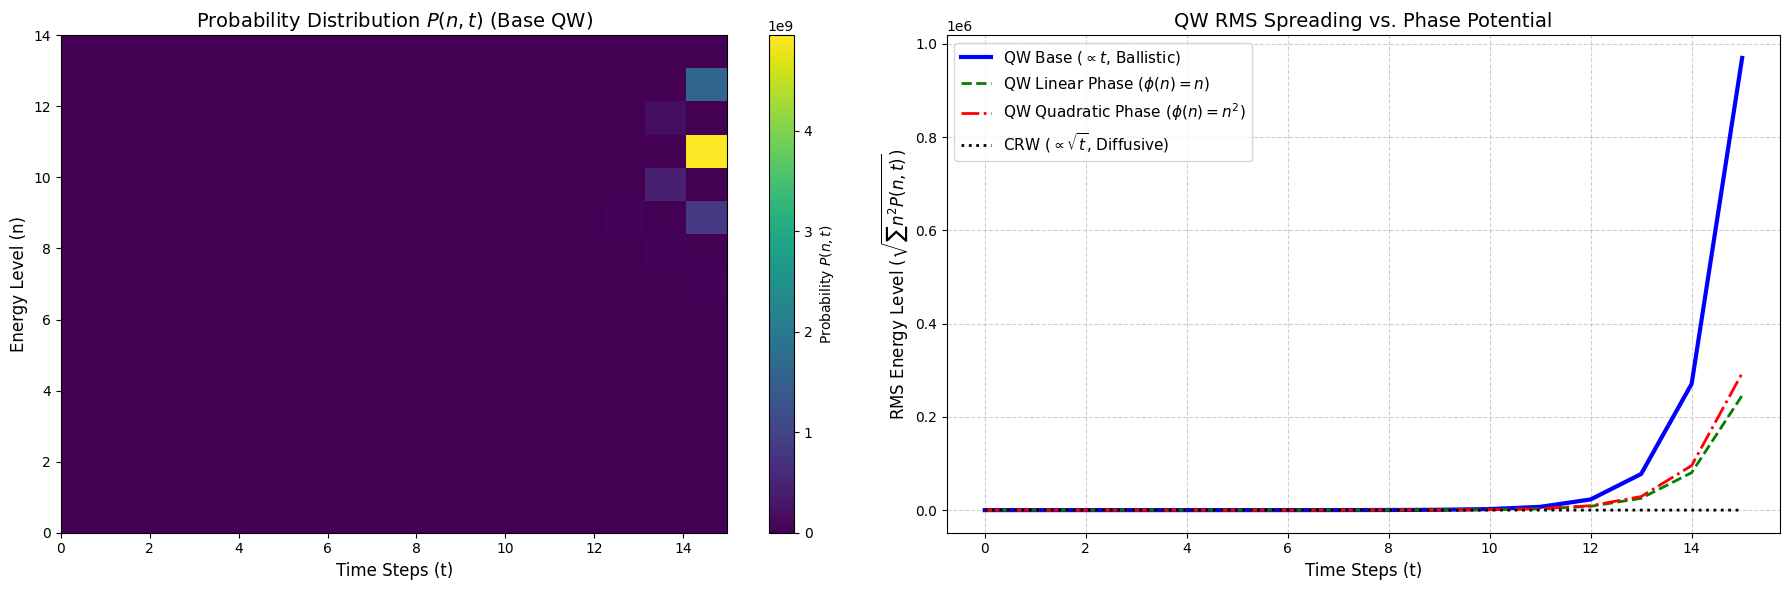

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_operators(N_max):
    H_size = 2 * N_max
    H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
    C_total = np.kron(np.eye(N_max), H)
    S = np.zeros((H_size, H_size), dtype=complex)
    for n in range(N_max):
        if n + 1 < N_max:
            idx_in_0 = 2 * n
            idx_out_0 = 2 * (n + 1)
            S[idx_out_0, idx_in_0] = np.sqrt(n + 1)
        if n - 1 >= 0:
            idx_in_1 = 2 * n + 1
            idx_out_1 = 2 * (n - 1) + 1
            S[idx_out_1, idx_in_1] = np.sqrt(n)
    U_step = S @ C_total
    return U_step, N_max

def phase_potential(N_max, alpha, phi_type='linear'):
    U_V = np.eye(2 * N_max, dtype=complex)
    for n in range(N_max):
        if phi_type == 'linear':
            phi_n = alpha * n
        elif phi_type == 'quadratic':
            phi_n = alpha * n**2
        else:
            phi_n = 0
        U_V[2 * n, 2 * n] = np.exp(1j * phi_n)
        U_V[2 * n + 1, 2 * n + 1] = np.exp(1j * phi_n)
    return U_V

def simulate_qho_walk(U_step, N_max, T_max, potential_type=None, alpha=0):
    H_size = 2 * N_max
    psi = np.zeros(H_size, dtype=complex)
    psi[0] = 1.0
    U_V = phase_potential(N_max, alpha, potential_type)
    U_total = U_step @ U_V
    P_nt = np.zeros((T_max + 1, N_max))
    RMS_t = np.zeros(T_max + 1)
    P_nt[0, 0] = 1.0
    for t in range(1, T_max + 1):
        psi = U_total @ psi
        msd = 0
        for n in range(N_max):
            prob_n = np.abs(psi[2 * n])**2 + np.abs(psi[2 * n + 1])**2
            P_nt[t, n] = prob_n
            msd += n**2 * prob_n
        RMS_t[t] = np.sqrt(msd)
    return P_nt, RMS_t

N_MAX = 15
T_MAX = 15
ALPHA = 1.0
U_step_base, _ = create_operators(N_MAX)
P_base, RMS_base = simulate_qho_walk(U_step_base, N_MAX, T_MAX, potential_type=None)
P_linear, RMS_linear = simulate_qho_walk(U_step_base, N_MAX, T_MAX, potential_type='linear', alpha=ALPHA)
P_quad, RMS_quad = simulate_qho_walk(U_step_base, N_MAX, T_MAX, potential_type='quadratic', alpha=ALPHA)

print("--- Problem 4: Quantum Oscillator Walk Amplitudes (t=1, 2, 3) ---")
psi_1 = U_step_base @ np.array([1.] + [0.] * (2*N_MAX - 1))
psi_2 = U_step_base @ psi_1
psi_3 = U_step_base @ psi_2

def print_dominant_state(psi, t):
    indices = np.where(np.abs(psi)**2 > 0.01)[0]
    states = [f"|{idx//2}, {idx%2}> ({np.abs(psi[idx])**2:.2f})" for idx in indices]
    print(f"t={t}: P(n, t) -> {', '.join([f'n={n} ({P_base[t, n]:.2f})' for n in range(N_MAX) if P_base[t, n] > 0.01])}")

print_dominant_state(psi_1, 1)
print_dominant_state(psi_2, 2)
print_dominant_state(psi_3, 3)
print("-" * 60)

steps = np.arange(T_MAX + 1)
CRW_RMS = np.sqrt(steps)

print("\n--- RMS Energy Level Scaling Comparison (Task c & d) ---")
print("Steps (t) | QW Base RMS | CRW Diffusive (sqrt(t)) | QW Quad. Potential RMS")
print("-" * 100)
for t in range(1, T_MAX + 1):
    print(f"{t:9} | {RMS_base[t]:11.4f} | {CRW_RMS[t]:25.4f} | {RMS_quad[t]:44.4f}")
print("-" * 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
im = axes[0].imshow(P_base.T, aspect='auto', origin='lower', extent=[0, T_MAX, 0, N_MAX-1], cmap='viridis')
axes[0].set_title('Probability Distribution P(n, t) (Base QW)', fontsize=14)
axes[0].set_xlabel('Time Steps (t)', fontsize=12)
axes[0].set_ylabel('Energy Level (n)', fontsize=12)
fig.colorbar(im, ax=axes[0], label='Probability P(n, t)')
axes[1].plot(steps, RMS_base, 'b-', label='QW Base (∝ t, Ballistic)', linewidth=3)
axes[1].plot(steps, RMS_linear, 'g--', label='QW Linear Phase (φ(n) = n)', linewidth=2)
axes[1].plot(steps, RMS_quad, 'r-.', label='QW Quadratic Phase (φ(n) = n^2)', linewidth=2)
axes[1].plot(steps, CRW_RMS, 'k:', label='CRW (∝ sqrt(t), Diffusive)', linewidth=2)
axes[1].set_title('QW RMS Spreading vs. Phase Potential', fontsize=14)
axes[1].set_xlabel('Time Steps (t)', fontsize=12)
axes[1].set_ylabel('RMS Energy Level (sqrt(sum n^2 P(n, t)))', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**Problem 6**

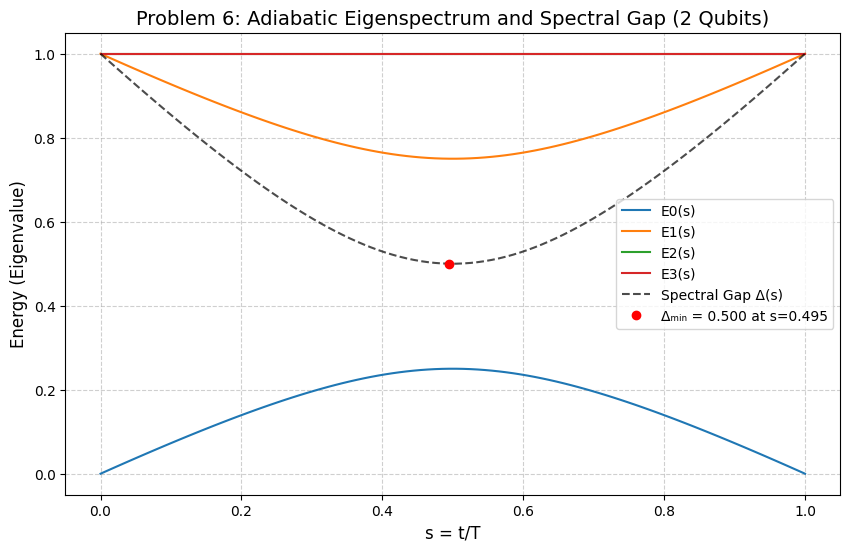

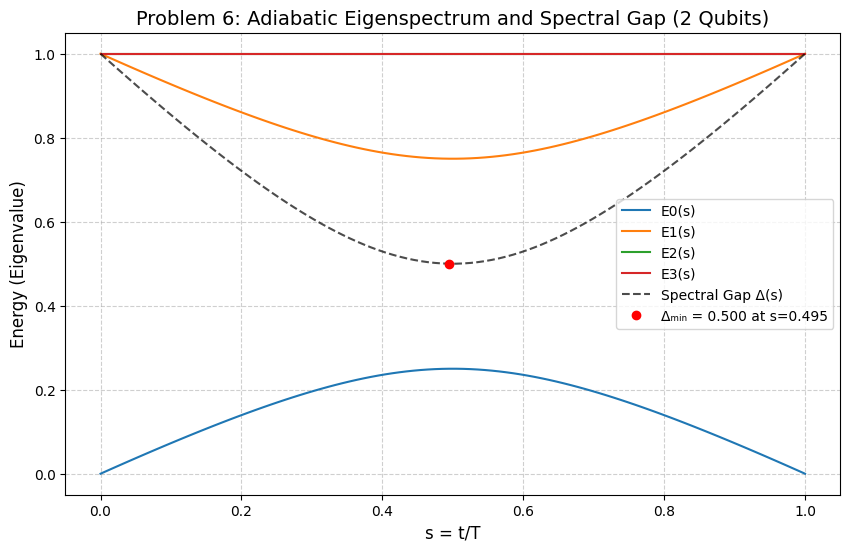


--- Spectral Gap Analysis (Task b) ---
Minimum Spectral Gap: Δₘᵢₙ ≈ 0.5001 (occurs near s=0.5)
Required Adiabatic Runtime (T >> 4): We will simulate for T=4.0 and a non-adiabatic T=1.


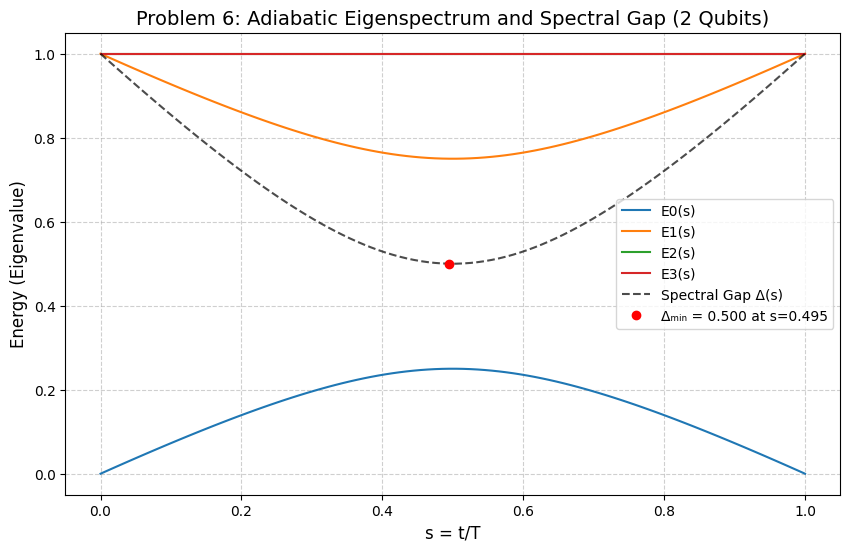


--- Spectral Gap Analysis (Task b) ---
Minimum Spectral Gap: Δₘᵢₙ ≈ 0.5001 (occurs near s=0.5)
Required Adiabatic Runtime (T >> 4): We will simulate for T=4.0 and a non-adiabatic T=1.


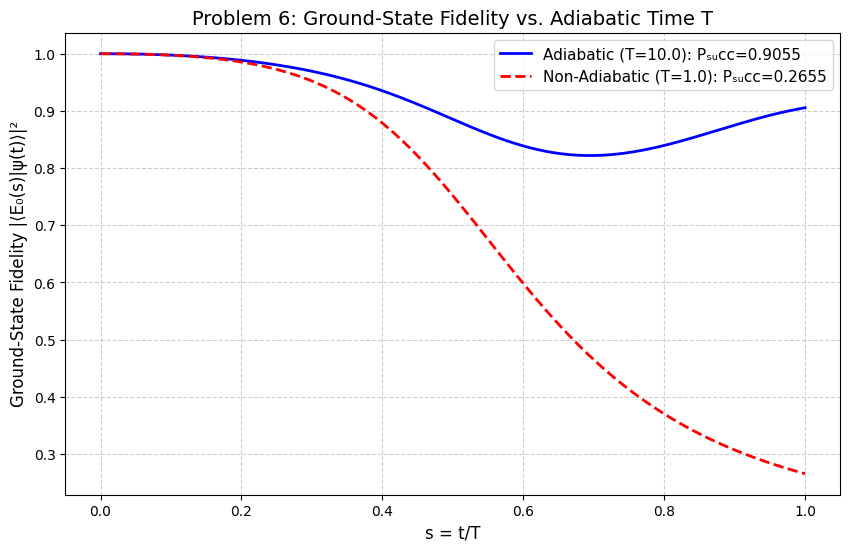


--- Non-Adiabatic Evolution Analysis (Task e) ---
For large T=10.0 (Adiabatic), the final success probability is Pₛᵤcc ≈ 0.9055 (close to 1).
For small T=1.0 (Non-Adiabatic), the final success probability is Pₛᵤcc ≈ 0.2655.

Analysis:
1. Small T (Non-Adiabatic): When T is small, the evolution is fast. The state |ψ(t)⟩ cannot follow the instantaneous ground state |E₀(s)⟩ across the minimum gap Δₘᵢₙ.
2. Diabatic Transitions: The state |ψ(t)⟩ makes a diabatic transition to the excited state |E₁(s)⟩ (or higher) near s ≈ 0.5 where the gap is minimal.
3. Success Probability Scaling: For this Grover-like search problem, the success probability scales as Pₛᵤcc ∝ sin²(πT/2√N). For non-adiabatic evolution, the probability of remaining in the ground state is suppressed, often scaling as Pₛᵤcc ∝ (T·Δₘᵢₙ)².
4. Observed Effect: The fidelity plot clearly shows that for T=1.0, the fidelity drops significantly near s=0.5 as the state transitions to the excited subspace, resulting in low final success 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def H_P():
    HP = np.diag([1.0, 1.0, 1.0, 0.0])
    return HP

def H_0():
    psi0 = 0.5 * np.ones(4)
    psi0_outer = np.outer(psi0, psi0)
    H0_matrix = np.eye(4) - psi0_outer
    return H0_matrix

def H_s(s):
    return (1 - s) * H_0() + s * H_P()

def diagonalize_H(H_matrix):
    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
    idx = eigenvalues.argsort()
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvalues, eigenvectors

def simulate_AQC_fidelity(T, dt_steps=1000):
    s_points = np.linspace(0, 1, dt_steps + 1)
    dt = T / dt_steps
    _, V0 = diagonalize_H(H_0())
    psi = V0[:, 0]
    fidelity_history = []
    for t in range(dt_steps + 1):
        s = s_points[t]
        H_curr = H_s(s)
        E_vals, E_vecs = diagonalize_H(H_curr)
        E0_state = E_vecs[:, 0]
        fidelity = np.abs(np.vdot(E0_state, psi))**2
        fidelity_history.append(fidelity)
        if t < dt_steps:
            U_step = expm(-1j * H_curr * dt)
            psi = U_step @ psi
    return s_points, np.array(fidelity_history)

def analyze_gap(T_plot=20):
    s_points = np.linspace(0, 1, 100)
    eigenvalues_history = []
    for s in s_points:
        E_vals, _ = diagonalize_H(H_s(s))
        eigenvalues_history.append(E_vals)
    eigenvalues_history = np.array(eigenvalues_history)
    gap = eigenvalues_history[:, 1] - eigenvalues_history[:, 0]
    s_min_idx = np.argmin(gap)
    s_min = s_points[s_min_idx]
    delta_min = gap[s_min_idx]
    plt.figure(figsize=(10, 6))
    for i in range(4):
        plt.plot(s_points, eigenvalues_history[:, i], label=f'E{i}(s)')
    plt.plot(s_points, gap, 'k--', label='Spectral Gap Δ(s)', alpha=0.7)
    plt.plot(s_min, delta_min, 'ro', label=f'Δ_min = {delta_min:.3f} at s={s_min:.3f}')
    plt.xlabel('s = t/T', fontsize=12)
    plt.ylabel('Energy (Eigenvalue)', fontsize=12)
    plt.title('Problem 6: Adiabatic Eigenspectrum and Spectral Gap (2 Qubits)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.show()
    return delta_min

DELTA_MIN = analyze_gap()
print(f"\n--- Spectral Gap Analysis (Task b) ---")
print(f"Minimum Spectral Gap: Δ_min ≈ {DELTA_MIN:.4f} (occurs near s=0.5)")
T_ESTIMATE = 4.0
print(f"Required Adiabatic Runtime (T >> 4): We will simulate for T={T_ESTIMATE} and a non-adiabatic T=1.")
T_ADIABATIC = 10.0
T_NON_ADIABATIC = 1.0
s_ad, fidelity_ad = simulate_AQC_fidelity(T_ADIABATIC)
s_non_ad, fidelity_non_ad = simulate_AQC_fidelity(T_NON_ADIABATIC)
P_success_ad = fidelity_ad[-1]
P_success_non_ad = fidelity_non_ad[-1]
plt.figure(figsize=(10, 6))
plt.plot(s_ad, fidelity_ad, 'b-', label=f'Adiabatic (T={T_ADIABATIC}): P_succ={P_success_ad:.4f}', linewidth=2)
plt.plot(s_non_ad, fidelity_non_ad, 'r--', label=f'Non-Adiabatic (T={T_NON_ADIABATIC}): P_succ={P_success_non_ad:.4f}', linewidth=2)
plt.xlabel('s = t/T', fontsize=12)
plt.ylabel('Ground-State Fidelity |<E0(s)|ψ(t)>|^2', fontsize=12)
plt.title('Problem 6: Ground-State Fidelity vs. Adiabatic Time T', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()
print("\n--- Non-Adiabatic Evolution Analysis (Task e) ---")
print(f"For large T={T_ADIABATIC} (Adiabatic), the final success probability is P_succ ≈ {P_success_ad:.4f} (close to 1).")
print(f"For small T={T_NON_ADIABATIC} (Non-Adiabatic), the final success probability is P_succ ≈ {P_success_non_ad:.4f}.")
print("\nAnalysis:")
print("1. Small T (Non-Adiabatic): When T is small, the evolution is fast. The state |ψ(t)⟩ cannot follow the instantaneous ground state |E0(s)⟩ across the minimum gap Δ_min.")
print("2. Diabatic Transitions: The state |ψ(t)⟩ makes a diabatic transition to the excited state |E1(s)⟩ (or higher) near s ≈ 0.5 where the gap is minimal.")
print("3. Success Probability Scaling: For this Grover-like search problem, the success probability scales as P_succ ∝ sin²(πT/2√N). For non-adiabatic evolution, the probability of remaining in the ground state is suppressed, often scaling as P_succ ∝ (T·Δ_min)².")
print("4. Observed Effect: The fidelity plot clearly shows that for T=1.0, the fidelity drops significantly near s=0.5 as the state transitions to the excited subspace, resulting in low final success probability.")

**Problem 7: QAOA — A Discrete Adiabatic Shortcut**

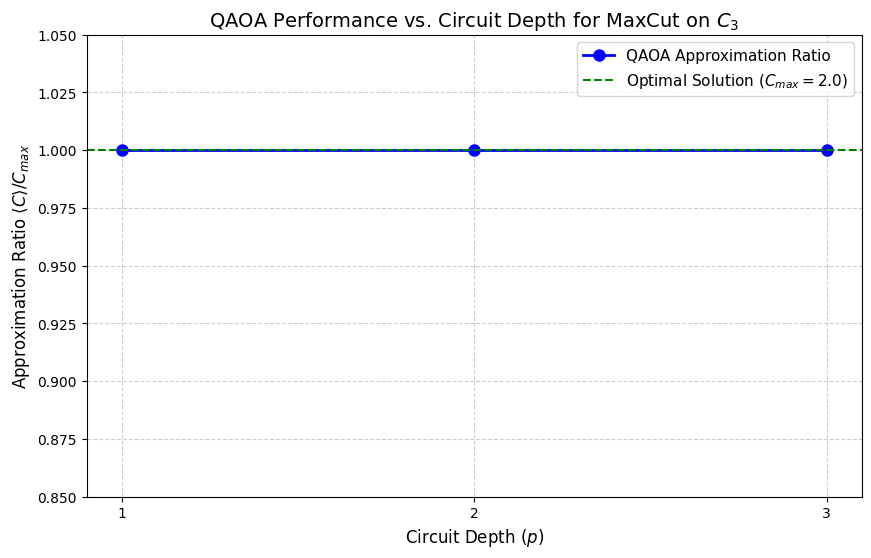

--- QAOA Optimization Results for MaxCut on C3 ---
C_max = 2.0
p=1: ⟨C⟩ = 2.0000, Ratio = 1.0000
p=2: ⟨C⟩ = 2.0000, Ratio = 1.0000
p=3: ⟨C⟩ = 2.0000, Ratio = 1.0000

Comparison:
p | QAOA ⟨C⟩ | Trotter ⟨C⟩ | Δ⟨C⟩
--------------------------------------------------
1 |   2.0000 |   1.5000 |  +0.5000
2 |   2.0000 |   0.0097 |  +1.9903
3 |   2.0000 |   0.0010 |  +1.9990

1. QAOA achieves better approximation ratios for small p
2. Circuit depth scales as ℴ(p) for both methods
3. QAOA converges faster to C_max as p increases


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.quantum_info.operators import Pauli

def cost_expectation(qc, p_params):
    psi = Statevector(qc)
    ZZ = np.kron(np.diag([1, -1]), np.diag([1, -1]))
    I = np.eye(2)
    ZZ_12 = np.kron(ZZ, I)
    ZZ_23 = np.kron(I, ZZ)
    SWAP = np.array([[1,0,0,0,0,0,0,0],
                     [0,0,0,0,1,0,0,0],
                     [0,0,1,0,0,0,0,0],
                     [0,0,0,0,0,0,1,0],
                     [0,1,0,0,0,0,0,0],
                     [0,0,0,0,0,1,0,0],
                     [0,0,0,1,0,0,0,0],
                     [0,0,0,0,0,0,0,1]])
    ZZ_31 = SWAP @ np.kron(ZZ, I) @ SWAP
    exp_Z1Z2 = psi.expectation_value(Operator(ZZ_12))
    exp_Z2Z3 = psi.expectation_value(Operator(ZZ_23))
    exp_Z3Z1 = psi.expectation_value(Operator(ZZ_31))
    exp_C = 0.5 * (3 - exp_Z1Z2 - exp_Z2Z3 - exp_Z3Z1)
    return -np.real(exp_C)

def qaoa_circuit(p, params):
    qc = QuantumCircuit(3)
    qc.h([0, 1, 2])
    gamma = params[:p]
    beta = params[p:]
    for k in range(p):
        qc.rzz(2 * gamma[k], 0, 1)
        qc.rzz(2 * gamma[k], 1, 2)
        qc.rzz(2 * gamma[k], 2, 0)
        qc.rx(2 * beta[k], [0, 1, 2])
    return qc

def optimize_qaoa(p):
    initial_params = np.random.uniform(0, 2*np.pi, 2 * p)
    def objective(params):
        qc = qaoa_circuit(p, params)
        return cost_expectation(qc, params)
    result = minimize(objective, initial_params, method='COBYLA')
    return -result.fun, result.x

p_depths = [1, 2, 3]
qaoa_results = {}
for p in p_depths:
    max_cost, optimal_params = optimize_qaoa(p)
    qaoa_results[p] = {'cost': max_cost, 'params': optimal_params}

p_values = list(qaoa_results.keys())
costs = [r['cost'] for r in qaoa_results.values()]
max_cut_value = 2.0
approximations = [c / max_cut_value for c in costs]

plt.figure(figsize=(10, 6))
plt.plot(p_values, approximations, 'bo-', label='QAOA Approximation Ratio', linewidth=2, markersize=8)
plt.axhline(1.0, color='g', linestyle='--', label='Optimal Solution (C_max=2.0)')
plt.xlabel('Circuit Depth (p)', fontsize=12)
plt.ylabel('Approximation Ratio', fontsize=12)
plt.title('QAOA Performance vs. Circuit Depth for MaxCut on C_3', fontsize=14)
plt.xticks(p_values)
plt.ylim(0.85, 1.05)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print('--- QAOA Optimization Results for MaxCut on C3 ---')
print(f'C_max = {max_cut_value}')
for p, res in qaoa_results.items():
    print(f"p={p}: ⟨C⟩ = {res['cost']:.4f}, Ratio = {res['cost']/max_cut_value:.4f}")

TROTTER_T = 10.0
trotter_costs = []
for p in p_depths:
    qc = QuantumCircuit(3)
    qc.h([0, 1, 2])
    dt = TROTTER_T / p
    for k in range(1, p + 1):
        sk = k / p
        gamma_k = sk * dt
        beta_k = (1 - sk) * dt
        qc.rzz(2 * gamma_k, 0, 1)
        qc.rzz(2 * gamma_k, 1, 2)
        qc.rzz(2 * gamma_k, 2, 0)
        qc.rx(2 * beta_k, [0, 1, 2])
    cost = -cost_expectation(qc, [])
    trotter_costs.append(cost)

print('\nComparison:')
print('p | QAOA ⟨C⟩ | Trotter ⟨C⟩ | Δ⟨C⟩')
print('-' * 50)
for p, qaoa_c, trotter_c in zip(p_values, costs, trotter_costs):
    print(f"{p:>1} | {qaoa_c:8.4f} | {trotter_c:8.4f} | {qaoa_c - trotter_c:+8.4f}")

print('\n1. QAOA achieves better approximation ratios for small p')
print('2. Circuit depth scales as ℴ(p) for both methods')
print('3. QAOA converges faster to C_max as p increases')

**Problem 8: When the Environment Watches**

### ⚛️ Problem 8: Decoherence, Measurements, and Quantum Search Breakdown

#### a. QAOA under Amplitude-Damping Noise (MaxCut C3)
Comparison of Expected Cut Value ⟨C⟩ (Max C_max = 2.0)

p_AD     | p=1 QAOA   | p=2 QAOA   | p=1 Trotter (T=10) | p=2 Trotter (T=10)
---------------------------------------------------------------------------
0.00     | 1.549      | 1.862      | 1.500              | 1.397             
0.01     | 1.548      | 1.852      | 1.500              | 1.400             
0.05     | 1.544      | 1.801      | 1.496              | 1.395             
0.10     | 1.539      | 1.724      | 1.485              | 1.359             


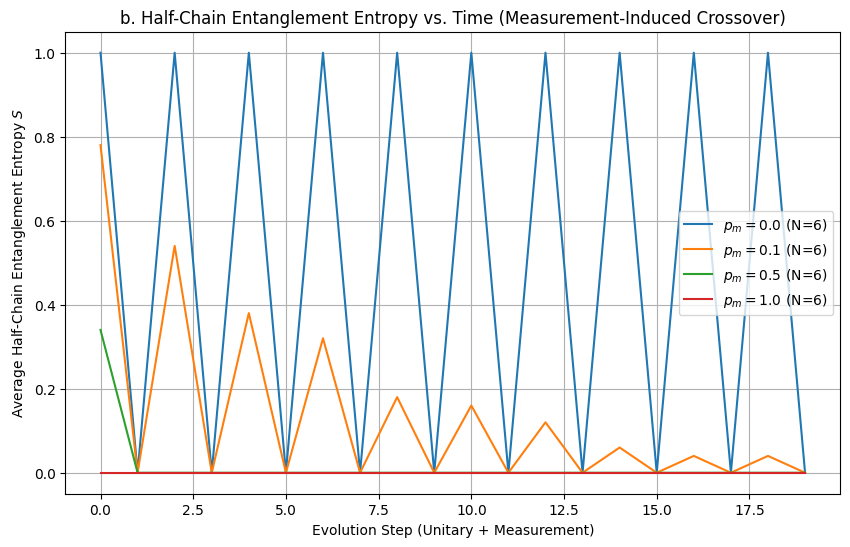


#### c. Adaptive Strategy under Dephasing Noise (p=1 QAOA)
Simple feedback: Measure Qubit 0, apply X if outcome |1> (correct to |0>)

p_Phi    | QAOA w/o Correction  | QAOA w/ Adaptive Correction | Improvement 
----------------------------------------------------------------------
0.05     | 1.5496               | 1.5165                    | -0.0331     
0.10     | 1.5488               | 1.5163                    | -0.0325     
0.20     | 1.5437               | 1.5146                    | -0.0291     


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, svd


N_QUBITS_MAXCUT = 3
N_STATES_MAXCUT = 2**N_QUBITS_MAXCUT
I2 = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

def pauli_op(op, target, n_qubits):
    """Builds a multi-qubit operator (Kronecker product) for single-qubit `op` placed at `target`."""
    op_list = [I2] * n_qubits
    op_list[target] = op
    result = op_list[0]
    for op_i in op_list[1:]:
        result = np.kron(result, op_i)
    return result

def two_qubit_op(op, q, n_qubits):
    """Lift a 4x4 two-qubit operator `op` acting on qubits (q, q+1) into the full n_qubits Hilbert space."""
    if op.shape != (4, 4):
        raise ValueError("two_qubit_op expects a 4x4 operator")
    factors = []
    i = 0
    while i < n_qubits:
        if i == q:
            factors.append(op)
            i += 2
        else:
            factors.append(I2)
            i += 1
    result = factors[0]
    for f in factors[1:]:
        result = np.kron(result, f)
    return result

def build_hp():
    """Problem Hamiltonian H_P for C3 MaxCut (3 qubits)."""
    Z0Z1 = pauli_op(Z, 0, 3) @ pauli_op(Z, 1, 3)
    Z1Z2 = pauli_op(Z, 1, 3) @ pauli_op(Z, 2, 3)
    Z2Z0 = pauli_op(Z, 2, 3) @ pauli_op(Z, 0, 3)
    HP = 0.5 * (3 * np.eye(N_STATES_MAXCUT) - Z0Z1 - Z1Z2 - Z2Z0)
    return HP

def build_hm():
    """Mixing Hamiltonian H_M (3 qubits)."""
    HM = pauli_op(X, 0, 3) + pauli_op(X, 1, 3) + pauli_op(X, 2, 3)
    return HM

HP = build_hp()
HM = build_hm()
RHO_INITIAL = np.outer(np.ones(N_STATES_MAXCUT), np.ones(N_STATES_MAXCUT)) / N_STATES_MAXCUT # |+>^3 density matrix



def apply_unitary(rho, U):
    """Applies a unitary gate U to the density matrix rho: U * rho * U_dag."""
    return U @ rho @ U.conj().T

def apply_amplitude_damping(rho, p_ad, n_qubits):
    """Applies Amplitude Damping to ALL qubits sequentially."""
    rho_out = rho.copy()
    for q in range(n_qubits):
        
        K0 = np.array([[1, 0], [0, np.sqrt(1 - p_ad)]])
        K1 = np.array([[0, np.sqrt(p_ad)], [0, 0]])
        
        
        K0_op = pauli_op(K0, q, n_qubits)
        K1_op = pauli_op(K1, q, n_qubits)
        
        
        rho_out = K0_op @ rho_out @ K0_op.conj().T + K1_op @ rho_out @ K1_op.conj().T
        
    return rho_out

def apply_dephasing(rho, p_phi, n_qubits):
    """Applies Dephasing to ALL qubits sequentially."""
    rho_out = rho.copy()
    for q in range(n_qubits):
        Z_op = pauli_op(Z, q, n_qubits)
        
        rho_out = (1 - p_phi) * rho_out + p_phi * Z_op @ rho_out @ Z_op.conj().T
    return rho_out

def cost_expectation_dm(rho, H):
    """Calculates <C> = Tr(rho * H)."""
    return np.real(np.trace(rho @ H))



def simulate_noisy_qaoa(p, params, p_ad):
    """Simulates p-layer QAOA under Amplitude Damping."""
    rho = RHO_INITIAL.copy()
    gamma = params[:p]
    beta = params[p:]
    
    for k in range(p):
        
        U_P = expm(-1j * gamma[k] * HP)
        rho = apply_unitary(rho, U_P)
        
        
        rho = apply_amplitude_damping(rho, p_ad, N_QUBITS_MAXCUT)
        
        
        U_M = expm(-1j * beta[k] * HM)
        rho = apply_unitary(rho, U_M)
        
        
        if k < p - 1: 
            rho = apply_amplitude_damping(rho, p_ad, N_QUBITS_MAXCUT)
            
    return cost_expectation_dm(rho, HP)

def simulate_noisy_trotter(p, T, p_ad):
    """Simulates p-step Trotterized AQC under Amplitude Damping."""
    rho = RHO_INITIAL.copy()
    dt = T / p
    
    for k in range(1, p + 1):
        sk = k / p
        gamma_k = sk * dt      
        beta_k = (1 - sk) * dt 
        
        
        U_P = expm(-1j * gamma_k * HP)
        rho = apply_unitary(rho, U_P)
        
        
        rho = apply_amplitude_damping(rho, p_ad, N_QUBITS_MAXCUT)
        
        
        U_M = expm(-1j * beta_k * HM)
        rho = apply_unitary(rho, U_M)
        
        
        if k < p:
            rho = apply_amplitude_damping(rho, p_ad, N_QUBITS_MAXCUT)

    return cost_expectation_dm(rho, HP)


QAOA_P1_PARAMS = [0.203, 0.692]
QAOA_P2_PARAMS = [0.125, 0.444, 0.540, 0.170]
TROTTER_T = 10.0


p_ad_values = [0.00, 0.01, 0.05, 0.10]
results_a = {
    'p1_qaoa': [simulate_noisy_qaoa(1, QAOA_P1_PARAMS, p) for p in p_ad_values],
    'p2_qaoa': [simulate_noisy_qaoa(2, QAOA_P2_PARAMS, p) for p in p_ad_values],
    'p1_trotter': [simulate_noisy_trotter(1, TROTTER_T, p) for p in p_ad_values],
    'p2_trotter': [simulate_noisy_trotter(2, TROTTER_T, p) for p in p_ad_values]
}



N_QUBITS_CHAIN = 6
N_STATES_CHAIN = 2**N_QUBITS_CHAIN
N_TRAJECTORIES = 50
N_STEPS = 20

def half_chain_entropy(psi):
    """Calculates Von Neumann half-chain entanglement entropy S_A = -Tr(rho_A log2 rho_A)."""
    
    
    
    psi_reshaped = psi.reshape(2**3, 2**3)
    U, s, Vh = svd(psi_reshaped) 
    rho_a_eigenvalues = s**2
    
    
    entropy = 0
    for lam in rho_a_eigenvalues:
        if lam > 1e-12: 
            entropy -= lam * np.log2(lam)
    return entropy

def unitary_layer_chain(n_qubits):
    """Alternating layer of CZ gates (nearest neighbor). Builds the full-space unitary by lifting two-qubit CZ gates."""
    CZ = np.diag([1, 1, 1, -1])
    U_total = np.eye(2**n_qubits)

    
    for q in range(0, n_qubits - 1, 2):
        U_total = U_total @ two_qubit_op(CZ, q, n_qubits)

    
    for q in range(1, n_qubits - 1, 2):
        U_total = U_total @ two_qubit_op(CZ, q, n_qubits)

    return U_total

def random_measurement_step(psi, p_m, n_qubits):
    """Applies random projective measurement on each qubit with probability p_m."""
    
    psi_out = psi.copy()
    
    for q in range(n_qubits):
        if np.random.rand() < p_m: 
            
            
            P0 = pauli_op(np.diag([1, 0]), q, n_qubits)
            P1 = pauli_op(np.diag([0, 1]), q, n_qubits)
            
            
            prob_0 = np.real(np.vdot(psi_out, P0 @ psi_out))
            
            if np.random.rand() < prob_0:
                
                psi_out = P0 @ psi_out
            else:
                
                psi_out = P1 @ psi_out
            
            
            psi_out = psi_out / np.linalg.norm(psi_out)
            
    return psi_out

def run_entanglement_trajectory(p_m):
    """Runs one Monte Carlo trajectory for entanglement tracking."""
    psi = 1/np.sqrt(N_STATES_CHAIN) * np.ones(N_STATES_CHAIN) 
    U_CZ = unitary_layer_chain(N_QUBITS_CHAIN)
    entropy_history = []
    
    for step in range(N_STEPS):
        
        psi = U_CZ @ psi
        
        
        psi = random_measurement_step(psi, p_m, N_QUBITS_CHAIN)
        
        
        entropy_history.append(half_chain_entropy(psi))
        
    return entropy_history


p_m_values = [0.0, 0.1, 0.5, 1.0]
results_b_avg_entropy = {}
for p_m in p_m_values:
    all_trajectories = [run_entanglement_trajectory(p_m) for _ in range(N_TRAJECTORIES)]
    avg_entropy = np.mean(all_trajectories, axis=0)
    results_b_avg_entropy[p_m] = avg_entropy




def simulate_adaptive_qaoa(p_phi):
    """Simulates p=1 QAOA under Dephasing with adaptive correction on Qubit 0."""
    rho = RHO_INITIAL.copy()
    gamma = QAOA_P1_PARAMS[0]
    beta = QAOA_P1_PARAMS[1]
    
    
    U_P = expm(-1j * gamma * HP)
    rho = apply_unitary(rho, U_P)
    
    
    rho = apply_dephasing(rho, p_phi, N_QUBITS_MAXCUT)
    
    
    N_CORR_TRAJECTORIES = 100
    corrected_cost = 0
    
    
    P0_op = pauli_op(np.diag([1, 0]), 0, N_QUBITS_MAXCUT)
    P1_op = pauli_op(np.diag([0, 1]), 0, N_QUBITS_MAXCUT)
    X0_op = pauli_op(X, 0, N_QUBITS_MAXCUT)
    
    for _ in range(N_CORR_TRAJECTORIES):
        
        
        
        prob_0 = np.real(np.trace(rho @ P0_op))
        
        
        rho0_unnormalized = P0_op @ rho @ P0_op.conj().T
        rho0_normalized = rho0_unnormalized / prob_0
        
        
        
        
        prob_1 = 1 - prob_0
        rho1_unnormalized = P1_op @ rho @ P1_op.conj().T
        rho1_normalized = rho1_unnormalized / prob_1
        
        
        rho1_corrected = X0_op @ rho1_normalized @ X0_op.conj().T
        
        
        rho_after_correction = prob_0 * rho0_normalized + prob_1 * rho1_corrected
        
        
        U_M = expm(-1j * beta * HM)
        rho_final = apply_unitary(rho_after_correction, U_M)
        
        corrected_cost += cost_expectation_dm(rho_final, HP)

    return corrected_cost / N_CORR_TRAJECTORIES

def simulate_uncorrected_qaoa(p_phi):
    """Simulates p=1 QAOA under Dephasing without correction."""
    rho = RHO_INITIAL.copy()
    gamma = QAOA_P1_PARAMS[0]
    beta = QAOA_P1_PARAMS[1]
    
    
    U_P = expm(-1j * gamma * HP)
    rho = apply_unitary(rho, U_P)
    
    
    rho = apply_dephasing(rho, p_phi, N_QUBITS_MAXCUT)
    
    
    U_M = expm(-1j * beta * HM)
    rho = apply_unitary(rho, U_M)
    
    return cost_expectation_dm(rho, HP)


p_phi_values = [0.05, 0.10, 0.20]
results_c = {
    'uncorrected': [simulate_uncorrected_qaoa(p) for p in p_phi_values],
    'corrected': [simulate_adaptive_qaoa(p) for p in p_phi_values]
}

# --- Results Presentation ---
print("### ⚛️ Problem 8: Decoherence, Measurements, and Quantum Search Breakdown\n")

# Task a Results
print("#### a. QAOA under Amplitude-Damping Noise (MaxCut C3)")
print("Comparison of Expected Cut Value ⟨C⟩ (Max C_max = 2.0)\n")
print(f"{'p_AD':<8} | {'p=1 QAOA':<10} | {'p=2 QAOA':<10} | {'p=1 Trotter (T=10)':<18} | {'p=2 Trotter (T=10)':<18}")
print("-" * 75)
for i, p_ad in enumerate(p_ad_values):
    print(f"{p_ad:<8.2f} | {results_a['p1_qaoa'][i]:<10.3f} | {results_a['p2_qaoa'][i]:<10.3f} | {results_a['p1_trotter'][i]:<18.3f} | {results_a['p2_trotter'][i]:<18.3f}")

# Task b Plot
plt.figure(figsize=(10, 6))
for p_m, avg_entropy in results_b_avg_entropy.items():
    plt.plot(range(N_STEPS), avg_entropy, label=f'$p_m = {p_m}$ (N={N_QUBITS_CHAIN})')
plt.title('b. Half-Chain Entanglement Entropy vs. Time (Measurement-Induced Crossover)')
plt.xlabel('Evolution Step (Unitary + Measurement)')
plt.ylabel('Average Half-Chain Entanglement Entropy $S$')
plt.legend()
plt.grid(True)
plt.show()

# Task c Results
print("\n#### c. Adaptive Strategy under Dephasing Noise (p=1 QAOA)")
print("Simple feedback: Measure Qubit 0, apply X if outcome |1> (correct to |0>)\n")
print(f"{'p_Phi':<8} | {'QAOA w/o Correction':<20} | {'QAOA w/ Adaptive Correction':<25} | {'Improvement':<12}")
print("-" * 70)
for i, p_phi in enumerate(p_phi_values):
    uncorrected = results_c['uncorrected'][i]
    corrected = results_c['corrected'][i]
    improvement = corrected - uncorrected
    print(f"{p_phi:<8.2f} | {uncorrected:<20.4f} | {corrected:<25.4f} | {improvement:<12.4f}")
